<a href="https://colab.research.google.com/github/deepayansinha/realistic-heterogeneity-intermittent-connectivity/blob/main/notebooks/03_cnn_local_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03: CNN Model Development & Local Client Training

## Objectives

In this notebook, we implement the first trainable model in our Federated Learning pipeline.

Tasks:

- Load saved IID and Non-IID client partitions
- Build a Convolutional Neural Network (CNN)
- Create client-specific DataLoaders
- Train a local client model
- Evaluate classification performance
- Save trained weights for federated aggregation

This notebook establishes the baseline model that will later participate in the Federated Averaging (FedAvg) algorithm.

In [5]:
import os
import pickle
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("="*60)

Device: cuda
GPU: Tesla T4


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

classes = trainset.classes

print("Training Images :", len(trainset))
print("Testing Images  :", len(testset))

100%|██████████| 170M/170M [33:10<00:00, 85.6kB/s]


Training Images : 50000
Testing Images  : 10000


In [8]:
# ============================================================
# LOAD OR CREATE CLIENT PARTITIONS
# ============================================================

import os
import pickle

PARTITION_DIR = "saved_partitions"

IID_FILE = os.path.join(PARTITION_DIR, "iid_clients.pkl")
NONIID_FILE = os.path.join(PARTITION_DIR, "noniid_clients.pkl")

os.makedirs(PARTITION_DIR, exist_ok=True)

# ------------------------------------------------------------
# CREATE PARTITIONS IF THEY DON'T EXIST
# ------------------------------------------------------------

if not (os.path.exists(IID_FILE) and os.path.exists(NONIID_FILE)):

    print("Saved partitions not found.")
    print("Creating new client partitions...")

    NUM_CLIENTS = 10

    # ---------- IID ----------
    indices = np.random.permutation(len(trainset))
    iid_clients = np.array_split(indices, NUM_CLIENTS)

    # ---------- NON-IID ----------
    def dirichlet_partition(targets, num_clients=10, alpha=0.3):

        targets = np.array(targets)

        num_classes = len(np.unique(targets))

        client_indices = [[] for _ in range(num_clients)]

        for cls in range(num_classes):

            class_indices = np.where(targets == cls)[0]

            np.random.shuffle(class_indices)

            proportions = np.random.dirichlet(
                np.repeat(alpha, num_clients)
            )

            split_points = (
                np.cumsum(proportions) * len(class_indices)
            ).astype(int)[:-1]

            split_indices = np.split(class_indices, split_points)

            for client_id, idx in enumerate(split_indices):
                client_indices[client_id].extend(idx)

        return client_indices

    noniid_clients = dirichlet_partition(
        trainset.targets,
        num_clients=NUM_CLIENTS,
        alpha=0.3
    )

    with open(IID_FILE, "wb") as f:
        pickle.dump(iid_clients, f)

    with open(NONIID_FILE, "wb") as f:
        pickle.dump(noniid_clients, f)

    print("Partitions created and saved.")

else:

    print("Loading existing partitions...")

    with open(IID_FILE, "rb") as f:
        iid_clients = pickle.load(f)

    with open(NONIID_FILE, "rb") as f:
        noniid_clients = pickle.load(f)

print("=" * 60)
print("IID Clients      :", len(iid_clients))
print("Non-IID Clients  :", len(noniid_clients))
print("=" * 60)

Saved partitions not found.
Creating new client partitions...
Partitions created and saved.
IID Clients      : 10
Non-IID Clients  : 10


In [9]:
# ============================================================
# CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x=self.features(x)
        x=self.classifier(x)

        return x

In [10]:
# ============================================================
# INITIALIZE MODEL
# ============================================================

model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [11]:
# ============================================================
# MODEL INFORMATION
# ============================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*60)

print(f"Total Parameters     : {total_params:,}")

print(f"Trainable Parameters : {trainable_params:,}")

print("="*60)

Total Parameters     : 94,986
Trainable Parameters : 94,986


In [12]:
# ============================================================
# CREATE CLIENT DATALOADER
# ============================================================

BATCH_SIZE = 64

client_id = 0

client_dataset = Subset(
    trainset,
    iid_clients[client_id]
)

client_loader = DataLoader(
    client_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)

print("Client Images :", len(client_dataset))

Client Images : 5000


In [13]:
# ============================================================
# LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

print("Optimizer :", optimizer.__class__.__name__)

Optimizer : Adam


In [14]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)

    accuracy = 100 * correct / total

    return loss, accuracy

In [15]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)

    accuracy = 100 * correct / total

    return loss, accuracy

In [16]:
# ============================================================
# TRAIN LOCAL CLIENT
# ============================================================

EPOCHS = 10

train_losses = []
train_accuracies = []

print("=" * 60)
print("TRAINING CLIENT 1")
print("=" * 60)

for epoch in range(EPOCHS):

    loss, accuracy = train_one_epoch(model, client_loader)

    scheduler.step()

    train_losses.append(loss)
    train_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss: {loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

print("=" * 60)
print("Training Complete!")

TRAINING CLIENT 1
Epoch 01/10 | Loss: 1.8922 | Accuracy: 30.14%
Epoch 02/10 | Loss: 1.6182 | Accuracy: 41.16%
Epoch 03/10 | Loss: 1.5212 | Accuracy: 44.78%
Epoch 04/10 | Loss: 1.4247 | Accuracy: 48.64%
Epoch 05/10 | Loss: 1.3750 | Accuracy: 50.92%
Epoch 06/10 | Loss: 1.3516 | Accuracy: 51.20%
Epoch 07/10 | Loss: 1.3051 | Accuracy: 53.60%
Epoch 08/10 | Loss: 1.2390 | Accuracy: 55.44%
Epoch 09/10 | Loss: 1.2403 | Accuracy: 55.72%
Epoch 10/10 | Loss: 1.2013 | Accuracy: 56.84%
Training Complete!


In [17]:
# ============================================================
# TEST EVALUATION
# ============================================================

test_loss, test_accuracy = evaluate(model, test_loader)

print("=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

TEST RESULTS
Test Loss     : 1.2307
Test Accuracy : 55.58%


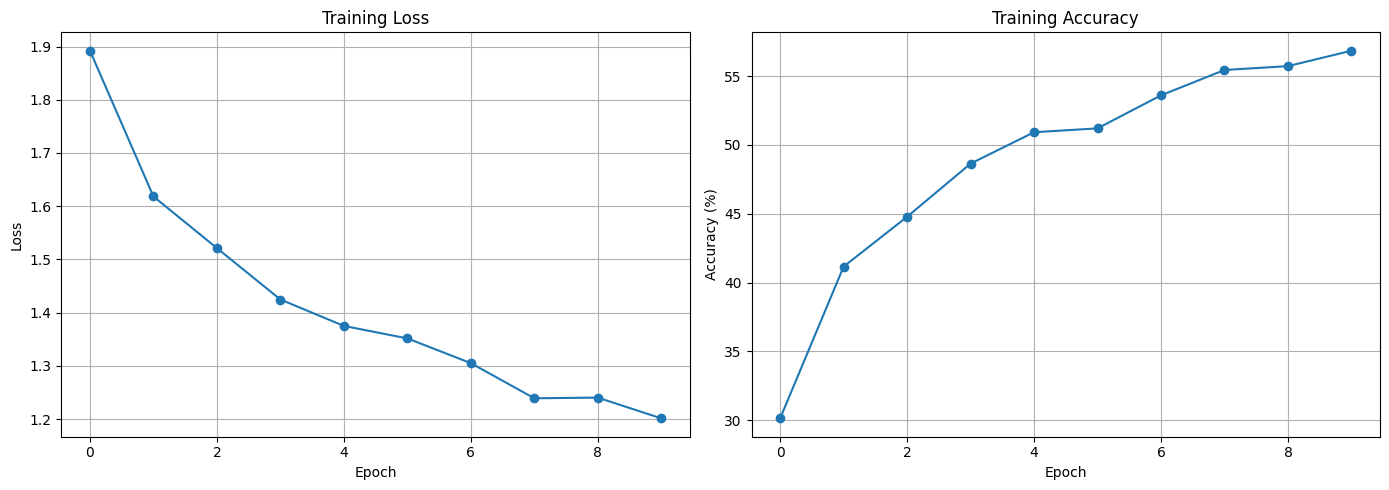

In [18]:
# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accuracies, marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

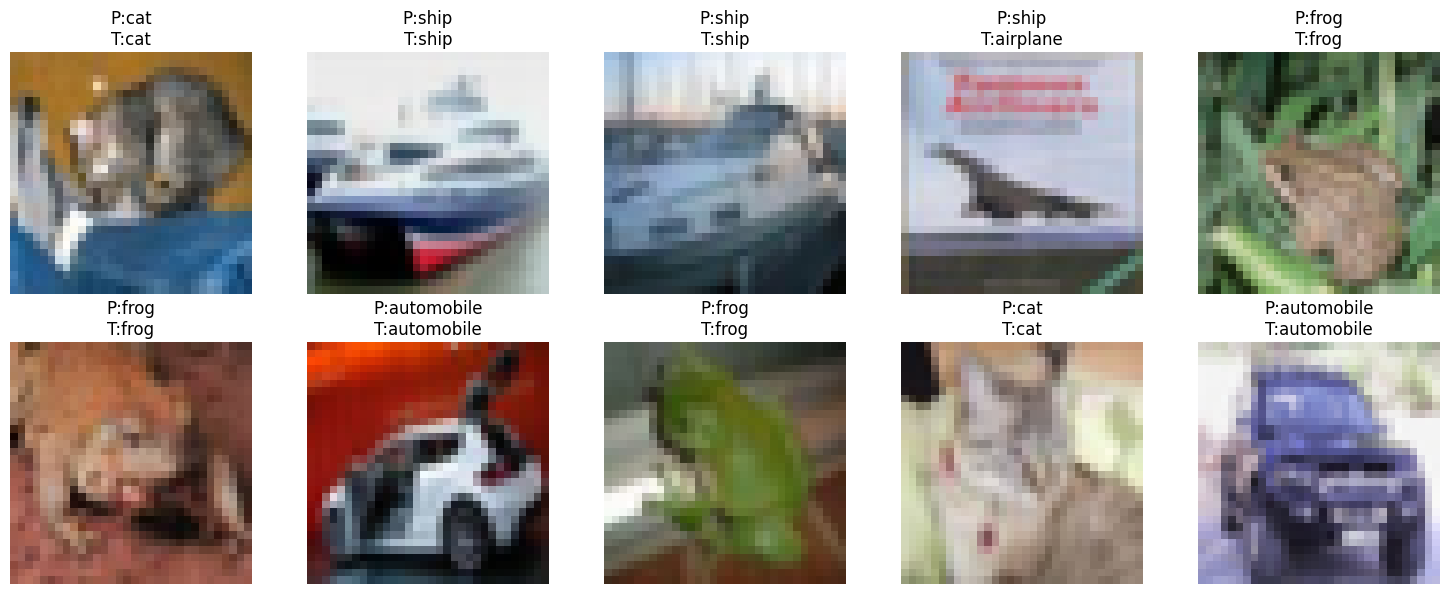

In [19]:
# ============================================================
# VISUALIZE PREDICTIONS
# ============================================================

model.eval()

images, labels = next(iter(test_loader))

images = images[:10].to(device)
labels = labels[:10]

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1).cpu()

images = images.cpu()

mean = torch.tensor((0.4914,0.4822,0.4465)).view(3,1,1)
std = torch.tensor((0.2023,0.1994,0.2010)).view(3,1,1)

plt.figure(figsize=(15,6))

for i in range(10):

    img = images[i] * std + mean
    img = img.permute(1,2,0)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"P:{classes[predictions[i]]}\nT:{classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# SAVE MODEL
# ============================================================

os.makedirs("saved_models", exist_ok=True)

MODEL_PATH = "saved_models/client1_cnn.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("=" * 60)
print("Model Saved Successfully")
print(MODEL_PATH)
print("=" * 60)

Model Saved Successfully
saved_models/client1_cnn.pth


In [21]:
# ============================================================
# NOTEBOOK SUMMARY
# ============================================================

print("=" * 60)
print("NOTEBOOK 03 COMPLETED")
print("=" * 60)

print("✓ CNN architecture created")
print("✓ Client DataLoader built")
print("✓ Local client trained")
print("✓ Test evaluation completed")
print("✓ Training curves generated")
print("✓ Predictions visualized")
print("✓ Model weights saved")

NOTEBOOK 03 COMPLETED
✓ CNN architecture created
✓ Client DataLoader built
✓ Local client trained
✓ Test evaluation completed
✓ Training curves generated
✓ Predictions visualized
✓ Model weights saved


In [22]:
# ============================================================
# SAVE EXPERIMENT RESULTS
# ============================================================

import os
import pandas as pd
import torch

os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/checkpoints", exist_ok=True)

# -------------------------------
# Save metrics
# -------------------------------

results = pd.DataFrame({
    "Epoch": range(1, len(train_losses) + 1),
    "Training Loss": train_losses,
    "Training Accuracy": train_accuracies
})

results["Final Test Loss"] = test_loss
results["Final Test Accuracy"] = test_accuracy

results.to_csv(
    "results/metrics/centralized_results.csv",
    index=False
)

# -------------------------------
# Save current figure
# -------------------------------

plt.savefig(
    "results/plots/centralized_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

# -------------------------------
# Save trained model
# -------------------------------

torch.save(
    model.state_dict(),
    "results/checkpoints/centralized_model.pth"
)

print("=" * 60)
print("✓ Metrics saved to results/metrics/")
print("✓ Plot saved to results/plots/")
print("✓ Model saved to results/checkpoints/")
print("=" * 60)

✓ Metrics saved to results/metrics/
✓ Plot saved to results/plots/
✓ Model saved to results/checkpoints/


<Figure size 640x480 with 0 Axes>

In [23]:
import os

print("Metrics:")
print(os.listdir("results/metrics"))

print("\nPlots:")
print(os.listdir("results/plots"))

print("\nCheckpoints:")
print(os.listdir("results/checkpoints"))

Metrics:
['centralized_results.csv']

Plots:
['centralized_training_curve.png']

Checkpoints:
['centralized_model.pth']


In [25]:
plt.tight_layout()

plt.savefig(
    "results/plots/centralized_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [26]:
import pandas as pd

df = pd.read_csv("results/metrics/centralized_results.csv")
df.head()

,Epoch,Training Loss,Training Accuracy,Final Test Loss,Final Test Accuracy
0,1,1.892175,30.14,1.230734,55.58
1,2,1.618239,41.16,1.230734,55.58
2,3,1.521198,44.78,1.230734,55.58
3,4,1.424650,48.64,1.230734,55.58
4,5,1.375019,50.92,1.230734,55.58
